# Neural Network from scratch using NumPy only

## Imports

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt

2026-03-14 17:14:44.736291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773508485.040044      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773508485.121431      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773508485.800105      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773508485.800159      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773508485.800163      55 computation_placer.cc:177] computation placer alr

# Data preparation

## Load dataset

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train = X_train.reshape(60000, 784).T / 255.0
X_test = X_test.reshape(10000, 784).T / 255.0

In [4]:
X_train.shape, X_test.shape

((784, 60000), (784, 10000))

# Main functions

## NN Initialization

In [5]:
def initialize_params():
    W1 = np.random.randn(16, 784) * np.sqrt(2. / 784)
    b1 = np.zeros((16, 1))
    W2 = np.random.randn(16, 16) * np.sqrt(2. / 784)
    b2 = np.zeros((16, 1))
    W3 = np.random.randn(10, 16) * np.sqrt(2. / 784)
    b3 = np.zeros((10, 1))
    return W1, b1, W2, b2, W3, b3

In [6]:
W1, b1, W2, b2, W3, b3 = initialize_params()

## One-Hot-Encoding

In [7]:
def one_hot(Y, length=10):
    one_hot_Y = np.zeros((length, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y

## Loss and Accuracy functions

In [8]:
def get_loss(y_true, p_pred):
    n = y_true.shape[1]
    # Додаємо 1e-15, щоб уникнути log(0)
    p_pred = np.clip(p_pred, 1e-15, 1 - 1e-15)
    
    # Сумуємо спочатку по класах (axis=0), потім беремо середнє по батчу
    loss = - (1/n) * np.sum(y_true * np.log(p_pred))
    return loss

In [10]:
def get_accuracy(Y_pred, Y_true_labels):
    predictions = np.argmax(Y_pred, axis=0)
    return np.sum(predictions == Y_true_labels) / Y_true_labels.size

## Activation Functions

In [11]:
def ReLU(x):
    return np.maximum(0, x)

In [12]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=0, keepdims=True)) 
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

## Forward Propagation

In [13]:
def pass_forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = W1 @ X + b1
    H1 = ReLU(Z1)
    
    Z2 = W2 @ H1 + b2
    H2 = ReLU(Z2)
    
    Z3 = W3 @ H2 + b3
    Y = softmax(Z3)

    return Z1, H1, Z2, H2, Z3, Y

## Backward Propagation

In [14]:
def ReLU_derivative(x):
    return x > 0

In [15]:
def backward_prop(Z1, H1, Z2, H2, Z3, Y, X, Target, W1, W2, W3, b1, b2, b3):
    n = Target.shape[1]
    
    dZ3 = Y - Target
    dW3 = (1/n) * (dZ3 @ H2.T)
    db3 = (1/n )* np.sum(dZ3, axis=1, keepdims=True)

    dZ2 = (W3.T @ dZ3) * ReLU_derivative(Z2)
    dW2 = (1/n) * (dZ2 @ H1.T)
    db2 = (1/n) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = (W2.T @ dZ2) * ReLU_derivative(Z1)
    dW1 = (1/n) * (dZ1 @ X.T)
    db1 = (1/n) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

## Update Params

In [16]:
def update_params(dW1, db1, dW2, db2, dW3, db3, W1, b1, W2, b2, W3, b3, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    W3 -= alpha * dW3
    b3 -= alpha * db3
    return W1, b1, W2, b2, W3, b3

# Model in Action

In [17]:
def train_model(X_train, Y_train_labels, epochs=10, batch_size=64, alpha=0.01):
    W1, b1, W2, b2, W3, b3 = initialize_params() 
    n_samples = n_samples = X_train.shape[1]

    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_sh = X_train[:, indices]
        Y_sh = Y_train_labels[indices]

        for i in range(0, n_samples, batch_size):
            X_batch = X_sh[:, i:i+batch_size]
            Y_batch_labels = Y_sh[i:i+batch_size]
            Target = one_hot(Y_batch_labels)
            # X, W1, b1, W2, b2, W3, b3
            Z1, H1, Z2, H2, Z3, Y_pred = pass_forward(X_batch, W1, b1, W2, b2, W3, b3)
            # Z1, H1, Z2, H2, Z3, Y, X, Target, W1, W2, W3, b1, b2, b3
            grads = backward_prop(Z1, H1, Z2, H2, Z3, Y_pred, X_batch, Target, W1, W2, W3, b1, b2, b3)
            # 
            W1, b1, W2, b2, W3, b3 = update_params(*grads, W1, b1, W2, b2, W3, b3, alpha)
        _, _, _, _, _, Y_full_pred = pass_forward(X_train, W1, b1, W2, b2, W3, b3)
        loss = get_loss(one_hot(Y_train_labels), Y_full_pred)
        acc = get_accuracy(Y_full_pred, Y_train_labels)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Accuracy: {acc*100:.2f}%")

    return W1, b1, W2, b2, W3, b3

In [24]:
W1, b1, W2, b2, W3, b3 = train_model(X_train, y_train, epochs=32, batch_size=64, alpha = 0.005)

Epoch 1/32 | Loss: 2.2966 | Accuracy: 17.99%
Epoch 2/32 | Loss: 2.2802 | Accuracy: 20.68%
Epoch 3/32 | Loss: 2.1749 | Accuracy: 27.77%
Epoch 4/32 | Loss: 1.7869 | Accuracy: 38.37%
Epoch 5/32 | Loss: 1.2426 | Accuracy: 63.85%
Epoch 6/32 | Loss: 0.8333 | Accuracy: 72.64%
Epoch 7/32 | Loss: 0.7086 | Accuracy: 77.00%
Epoch 8/32 | Loss: 0.6432 | Accuracy: 79.74%
Epoch 9/32 | Loss: 0.5948 | Accuracy: 81.70%
Epoch 10/32 | Loss: 0.5556 | Accuracy: 83.13%
Epoch 11/32 | Loss: 0.5205 | Accuracy: 84.34%
Epoch 12/32 | Loss: 0.4934 | Accuracy: 85.29%
Epoch 13/32 | Loss: 0.4671 | Accuracy: 86.21%
Epoch 14/32 | Loss: 0.4425 | Accuracy: 87.13%
Epoch 15/32 | Loss: 0.4193 | Accuracy: 87.77%
Epoch 16/32 | Loss: 0.3944 | Accuracy: 88.85%
Epoch 17/32 | Loss: 0.3747 | Accuracy: 89.41%
Epoch 18/32 | Loss: 0.3601 | Accuracy: 89.69%
Epoch 19/32 | Loss: 0.3493 | Accuracy: 90.08%
Epoch 20/32 | Loss: 0.3393 | Accuracy: 90.39%
Epoch 21/32 | Loss: 0.3302 | Accuracy: 90.58%
Epoch 22/32 | Loss: 0.3223 | Accuracy: 90.8

## Test

In [40]:
def get_pred(W1, b1, W2, b2, W3, b3, X_test, y_test, n):
    x = X_test[:, n].reshape(-1, 1)
    y = y_test[n]
    _, _, _, _, _, Y_pred = pass_forward(x, W1, b1, W2, b2, W3, b3)
    prediction = np.argmax(Y_pred)
    
    print(f"Передбачення мережі: {prediction}")
    print(f"Реальна цифра: {y}")
    
    # Виводимо саму картинку
    plt.imshow(x.reshape(28, 28), cmap='gray')
    plt.title(f"Target: {y} | Prediction: {prediction}")
    plt.show()
    
    return Y_pred

Передбачення мережі: 6
Реальна цифра: 6


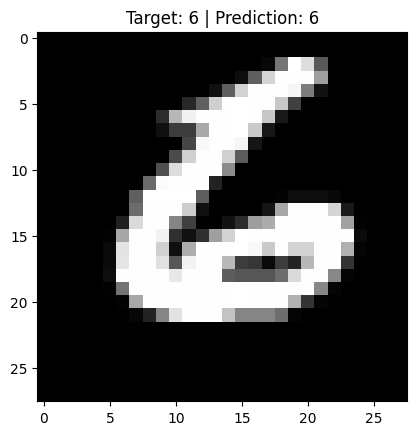

In [59]:
Y_pred = get_pred(W1, b1, W2, b2, W3, b3, X_test, y_test, 9999)

In [56]:
_, _, _, _, _, Y_test_pred = pass_forward(X_test, W1, b1, W2, b2, W3, b3)
test_acc = get_accuracy(Y_test_pred, y_test)
print(f"Точність на тестових даних: {test_acc * 100:.2f}%")

Точність на тестових даних: 92.35%
